In [1]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics

# Load data
df = pd.read_parquet('data_exjobb_070425.parquet')
df.head()

,TransactionId,SalePrice,Lat,Lon,BuildingAge,UtilityArea,LotArea,QualityScore,CloseToBeach,EnergyPerformance,...,MunicipalityMoveInFromCountyFrac,MunicipalityMoveOutToCountyFrac,MunicipalityMoveInFrac2yrChangeMean,MunicipalityMoveOutFrac2yrChangeMean,MunicipalityMoveInFromCountyFrac2yrChangeMean,MunicipalityMoveOutToCountyFrac2yrChangeMean,MunicipalityPopulationMeanDeviation,MedianRentMunicipality,MedianRentMunicipality2yrFracChangeMean,MedianRentMunicipalityMeanDeviation
0,10006194,3200000,56.742153,16.291778,48,143,480,36,0,60.0,...,0.025551,0.021314,0.001816,0.004082,0.000930,0.003437,4.373830,1155.0,0.091030,1.123790
1,10006232,1700000,57.278909,13.646019,54,120,750,32,0,114.0,...,0.010123,0.013869,-0.007777,0.006713,-0.001110,0.002518,1.843030,999.0,0.013451,0.972005
2,10006302,3500000,58.328009,15.103299,47,169,592,30,0,NaN,...,0.034871,0.028112,-0.003267,0.003278,-0.000932,0.000765,1.738860,1046.0,0.075010,1.017735
3,10006371,11200000,57.739437,14.122176,128,250,3311,30,0,88.0,...,0.013410,0.012764,-0.001062,0.001830,0.000457,0.000039,8.857676,1059.0,0.061507,1.030384
4,10006399,591000,57.784585,16.146614,112,87,3406,28,0,101.0,...,0.006766,0.006466,-0.001024,-0.000181,0.000441,0.000045,2.279611,909.0,0.009151,0.884437


In [2]:
def remove_non_numbers(data):
    """Remove colums with data which are not numbers and return the matrix, without the columns, and the indexes of the removed rows."""
    del_data = data.copy()
    del_idx = {}

    # Removing all non int or float type features looping from the end.
    iterate = len(del_data[0,:])-1
    for i in range(iterate+1):
        if type(del_data[0,iterate-i]) != float and type(del_data[0,iterate-i]) != int:
            # print(iterate-i, type(del_data[0,iterate-i]), data[0,iterate-i])
            del_data = np.delete(del_data, obj=iterate-i, axis=1)
            del_idx[iterate-i] = iterate-i
    """
    for i in range(len(del_data[0,:])):
        print(i, type(del_data[0,i]), del_data[0,i])

    for i in range(len(data[0,:])):
    print(i, type(data[0,i]), data[0,i])
        """
    return del_data, del_idx

In [3]:
# Chaning to numpy array
df = df.fillna(0)
data = df.to_numpy()

data, removed_indices = remove_non_numbers(data)
print("Removed indices:", removed_indices)



data = data.astype(float) # Changing from type object to float so that numpy functions work properly.

# Divide the data set into training and testing data
percent = 0.10  # Fraction used for testing
samples = int(len(data[:,None]) * percent)

training_data, testing_data = train_test_split(data, test_size=samples)

print('X1 shape: ', training_data.shape)
print('X2 shape: ', testing_data.shape)


data_points = 200
play_data = data[0:data_points, 1:4] # Only using a part of the data.

data = play_data


Removed indices: {153: 153, 49: 49, 48: 48, 40: 40, 39: 39, 32: 32, 26: 26, 25: 25, 24: 24, 23: 23, 17: 17, 15: 15, 10: 10, 0: 0}
X1 shape:  (82467, 160)
X2 shape:  (9163, 160)


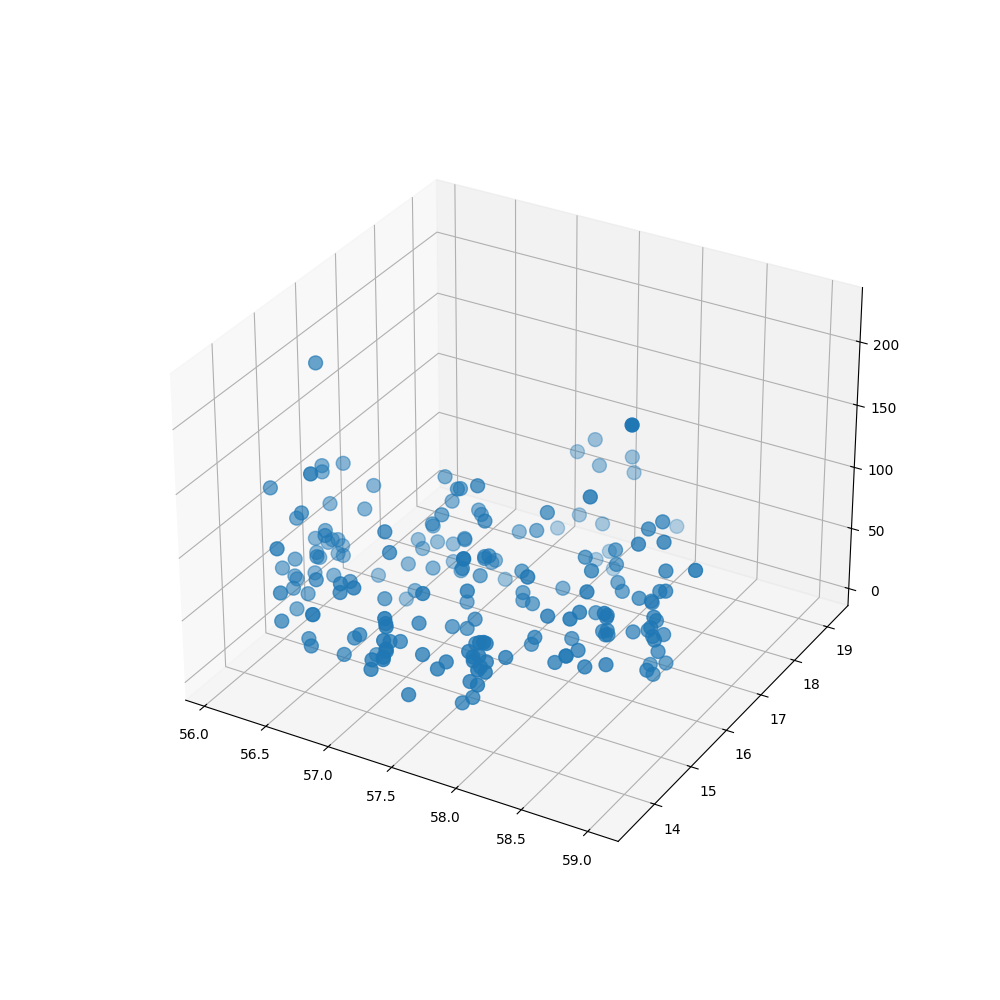

In [21]:
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]

%matplotlib widget

fig = plt.figure(figsize = (10,10))
ax = plt.axes(projection='3d')
ax.grid()
ax.scatter(x, y, z, s = 100)

In [13]:
def abs_max_norm(data, axis=1):
    """Using the normalize_feature function on an np.array along a chosen axis."""
    norm_data = np.zeros_like(data)
    for i in range(data.shape[axis]):
        norm_data[:,i] = abs_max_norm_feature(data[:,i])
    return norm_data

def abs_max_norm_feature(feature):
    abs_feature = np.abs(feature)
    abs_max = abs_feature.max()
    return feature / abs_max

def normalize_feature(feature):
    """Min-max normalization."""
    # This retains the relative position of the data points.
    return (feature-np.min(feature)) / (np.max(feature)-np.min(feature))

def normalize(data, axis=1):
    """Using the normalize_feature function on an np.array along a chosen axis."""
    norm_data = np.zeros_like(data)
    for i in range(data.shape[axis]):
        norm_data[:,i] = normalize_feature(data[:,i])
    return norm_data

In [ ]:
abs_norm = abs_max_norm(data)
print(abs_norm)

abs_feature = np.abs(data[:, 1])
abs_max = abs_feature.max()

# print(data[:, 1], abs_max)

[[0.96154342 0.84743387 0.21238938]
 [0.97063921 0.70981198 0.23893805]
 [0.98841709 0.78561392 0.2079646 ]
 [0.97844323 0.73457974 0.56637168]
 [0.97920832 0.83988301 0.49557522]
 [0.9677393  0.8383681  0.49557522]
 [0.97692923 0.76516087 0.18584071]
 [0.95641975 0.82041464 0.37610619]
 [0.97719898 0.95835247 0.00884956]
 [0.97318784 0.73308931 0.40707965]
 [0.97254502 0.82222017 0.32743363]
 [0.98420761 0.84025438 0.37610619]
 [0.95215856 0.76758536 0.22123894]
 [0.97592735 0.7241109  0.18584071]
 [0.97863516 0.96883064 0.40707965]
 [0.98957385 0.78481899 0.42477876]
 [0.95674213 0.7054812  0.49557522]
 [0.95173148 0.81003178 0.51769912]
 [0.99474563 0.84004291 0.34070796]
 [0.98118963 0.79735815 0.14159292]
 [0.96311822 0.72691266 0.12389381]
 [0.97325397 0.7848523  0.37610619]
 [0.99475845 0.81908118 0.26106195]
 [0.95688236 0.70694927 0.23893805]
 [0.97947206 0.7356548  0.2300885 ]
 [0.97642094 0.75946344 0.38053097]
 [0.97951235 0.73563174 0.21681416]
 [0.96654277 0.85550217 0.26

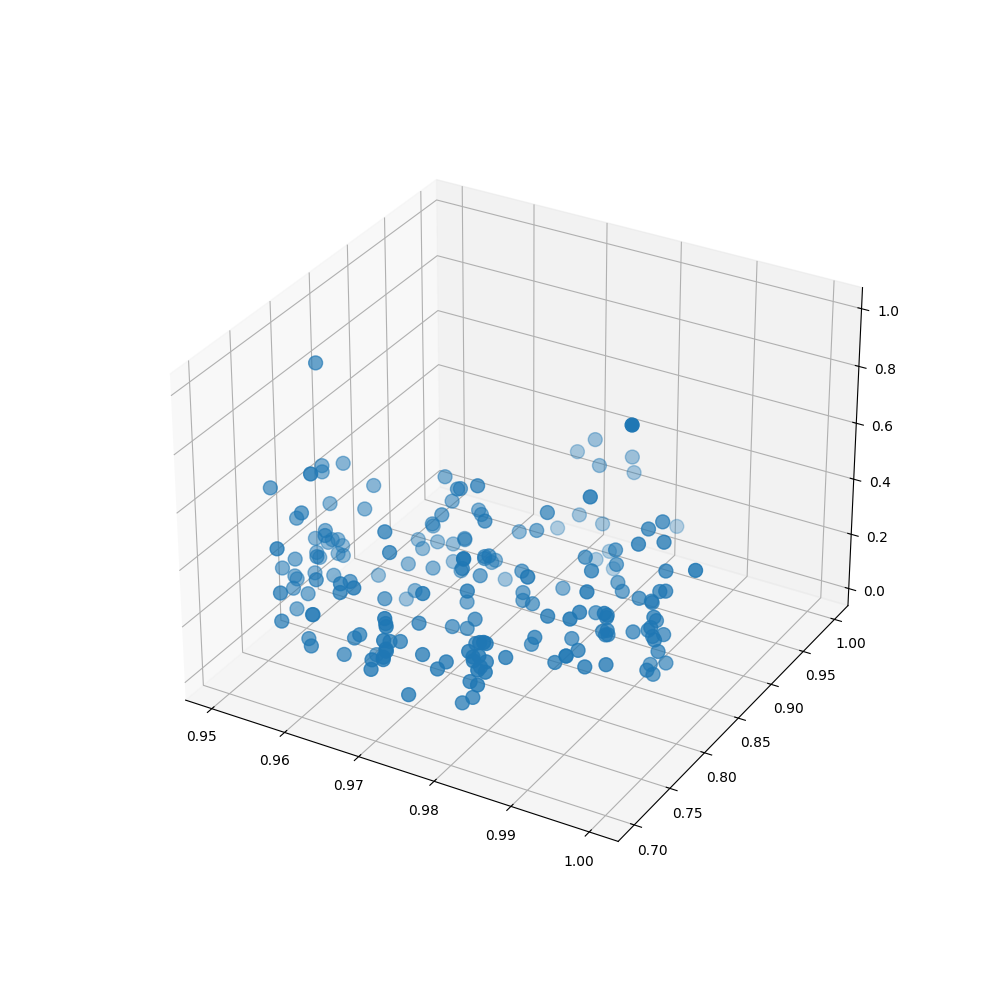

In [20]:
x = abs_norm[:, 0]
y = abs_norm[:, 1]
z = abs_norm[:, 2]

%matplotlib widget

fig = plt.figure(figsize = (10,10))
ax = plt.axes(projection='3d')
ax.grid()
ax.scatter(x, y, z, s = 100)